In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

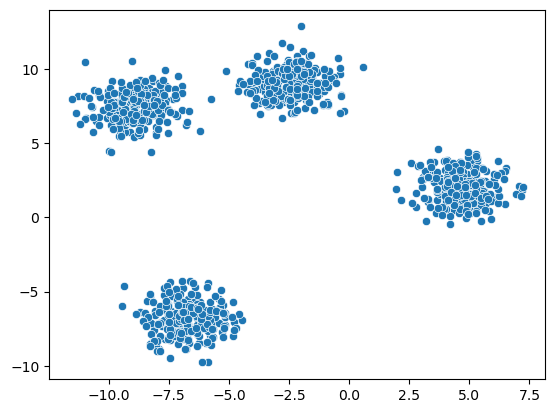

In [4]:
sns.scatterplot(x=X[:,0],y=X[:,1])

In [6]:
# K means clustering
from sklearn.cluster import KMeans

In [7]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [8]:
labels = kmeans.fit_predict(X)

<Axes: >

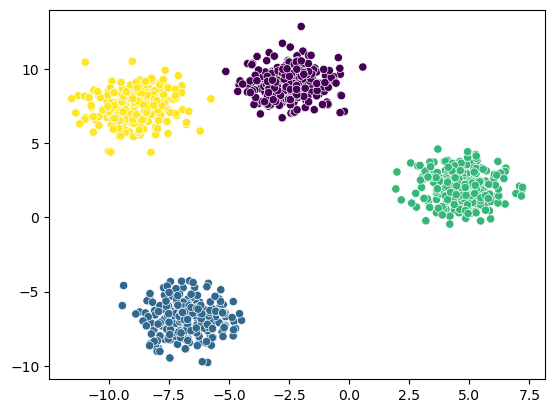

In [9]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=labels)

### Choose our K value - elbow, silhouette score

In [10]:
# Elbow method
# manual way to fin elbow point (K)
wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

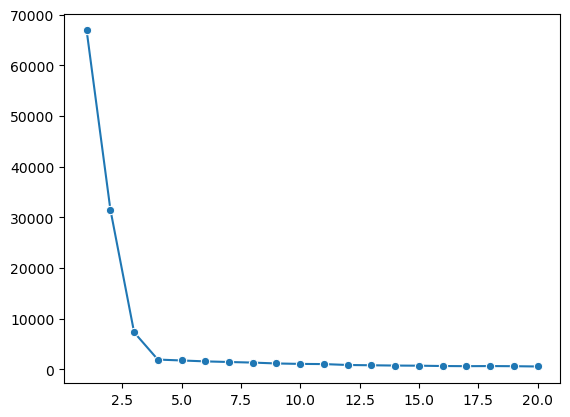

In [11]:
sns.lineplot(x=range(1, 21), y=wcss, marker="o")

In [12]:
# Automatic way to find K using library
!pip install kneed

In [13]:
from kneed import KneeLocator

In [17]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")
print("optimal K:", knee.knee)
print("optimal K:", knee.elbow)

optimal K: 4
optimal K: 4


### Silhouette Score

In [19]:
from sklearn.metrics import silhouette_score

In [20]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

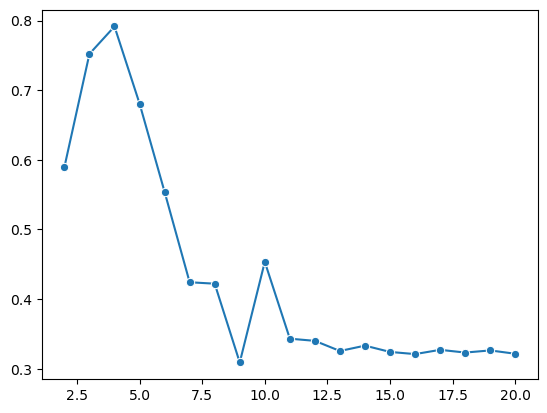

In [21]:
sns.lineplot(x=range(2, 21), y=ss, marker="o")